In [103]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
%matplotlib inline

In [104]:
data = np.loadtxt("data/ex1data1.txt", delimiter=',')
X_train = data[:, 0]
y_train = data[:, 1]

print("Type of x_train:",type(X_train))
print("First five elements of x_train are:\n", X_train[:5]) 
print("\nType of y_train:",type(y_train))
print("First five elements of y_train are:\n", y_train[:5])  

Type of x_train: <class 'numpy.ndarray'>
First five elements of x_train are:
 [6.1101 5.5277 8.5186 7.0032 5.8598]

Type of y_train: <class 'numpy.ndarray'>
First five elements of y_train are:
 [17.592   9.1302 13.662  11.854   6.8233]


In [105]:
print ('The shape of x_train is:', X_train.shape)
print ('The shape of y_train is: ', y_train.shape)
print ('Number of training examples (m):', len(X_train))

The shape of x_train is: (97,)
The shape of y_train is:  (97,)
Number of training examples (m): 97


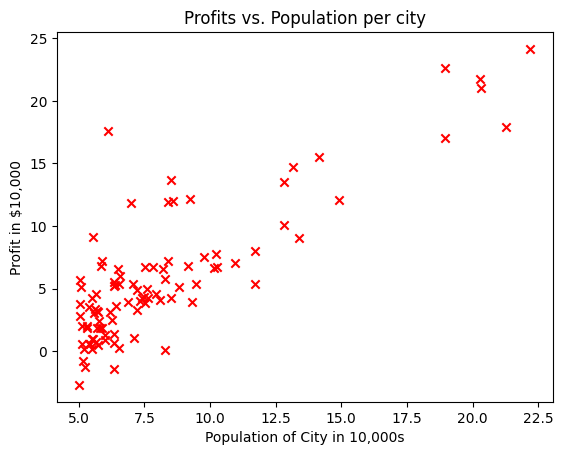

In [106]:
plt.scatter(X_train, y_train, marker='x', c='r') 

# Set the title
plt.title("Profits vs. Population per city")
# Set the y-axis label
plt.ylabel('Profit in $10,000')
# Set the x-axis label
plt.xlabel('Population of City in 10,000s')
plt.show()

1. Chi phí mất mát (Cost Function)

In [107]:
def compute_cost(X, y, w, b): 
    # Số lượng mẫu
    m = X.shape[0] 
    
    # Biến lưu tổng chi phí
    total_cost = 0
    cost_sum = 0
    
    # Tính toán hàm mất mát (Cost Function) cho mỗi mẫu dữ liệu
    for i in range(m):
        # Tính giá trị dự đoán (f_wb) cho mẫu i
        f_wb = np.dot(X[i], w) + b  # X[i] là vector đặc trưng, w là vector trọng số
        cost = (f_wb - y[i]) ** 2  # Hàm mất mát MSE
        cost_sum += cost  # Cộng dồn chi phí

    # Tính tổng chi phí (J(w, b))
    total_cost = (1 / (2 * m)) * cost_sum
    
    return total_cost


2. Tính toán Gradient của hàm mất mát để cập nhật w và b

In [108]:
def compute_gradient(X, y, w, b): 
    # Số lượng mẫu
    m = X.shape[0]
    
    # Khởi tạo các giá trị của gradient
    dj_dw = np.zeros_like(w)  # Khởi tạo dj_dw là một vector cùng kích thước với w
    dj_db = 0
    
    # Tính toán gradient cho mỗi mẫu
    for i in range(m):
        # Tính giá trị dự đoán cho mẫu i
        f_wb = np.dot(X[i], w) + b  # Tích vô hướng giữa X[i] và w cộng với bias b
        
        # Tính gradient đối với w và b
        dj_dw_i = (f_wb - y[i]) * X[i]  # Gradient theo w (công thức MSE)
        dj_db_i = f_wb - y[i]  # Gradient theo b
        
        # Cộng dồn gradient
        dj_dw += dj_dw_i
        dj_db += dj_db_i

    # Tính giá trị trung bình của gradient
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db


3. Giảm giá trị của hàm mất mát

In [109]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    # An array to store cost J and w's at each iteration — primarily for graphing later
    J_history = []
    w_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_dw, dj_db = gradient_function(X, y, w, b)  

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            cost =  cost_function(X, y, w, b)
            J_history.append(cost)

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0 or i == (num_iters-1):
            w_history.append(w)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
        
    return w, b, J_history, w_history #return w and J,w history for graphing

In [110]:
initial_w = 0.
initial_b = 0.

# some gradient descent settings
iterations = 1500
alpha = 0.01

w,b,_,_ = gradient_descent(X_train ,y_train, initial_w, initial_b, 
                     compute_cost, compute_gradient, alpha, iterations)
print("w,b found by gradient descent:", w, b)

Iteration    0: Cost     6.74   
Iteration  150: Cost     5.31   
Iteration  300: Cost     4.96   
Iteration  450: Cost     4.76   
Iteration  600: Cost     4.64   
Iteration  750: Cost     4.57   
Iteration  900: Cost     4.53   
Iteration 1050: Cost     4.51   
Iteration 1200: Cost     4.50   
Iteration 1350: Cost     4.49   
Iteration 1499: Cost     4.48   
w,b found by gradient descent: 1.166362350335582 -3.63029143940436


In [111]:
m = X_train.shape[0]
predicted = np.zeros(m)

for i in range(m):
    predicted[i] = w * X_train[i] + b

Text(0.5, 0, 'Population of City in 10,000s')

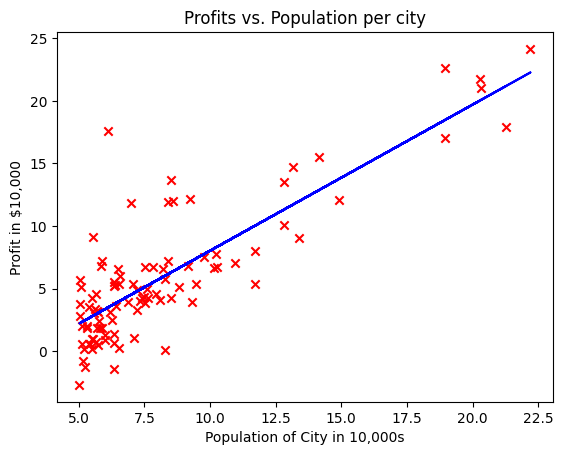

In [112]:
# Plot the linear fit
plt.plot(X_train, predicted, c = "b")

# Create a scatter plot of the data. 
plt.scatter(X_train, y_train, marker='x', c='r') 

# Set the title
plt.title("Profits vs. Population per city")
# Set the y-axis label
plt.ylabel('Profit in $10,000')
# Set the x-axis label
plt.xlabel('Population of City in 10,000s')

In [113]:
predict1 = 3.5 * w + b
print('For population = 35,000, we predict a profit of $%.2f' % (predict1*10000))

predict2 = 7.0 * w + b
print('For population = 70,000, we predict a profit of $%.2f' % (predict2*10000))

For population = 35,000, we predict a profit of $4519.77
For population = 70,000, we predict a profit of $45342.45


Iteration    0: Cost 19341946689.89   
Iteration  150: Cost 834046538.20   
Iteration  300: Cost 72249193.91   
Iteration  450: Cost 34998363.99   
Iteration  600: Cost 32932802.40   
Iteration  750: Cost 32606840.79   
Iteration  900: Cost 32380238.80   
Iteration 1050: Cost 32171681.15   
Iteration 1200: Cost 31976356.32   
Iteration 1350: Cost 31793256.14   
Iteration 1499: Cost 31622715.25   
w,b found by gradient descent: [36518.63299362 44854.48739992] 181599.94848807956


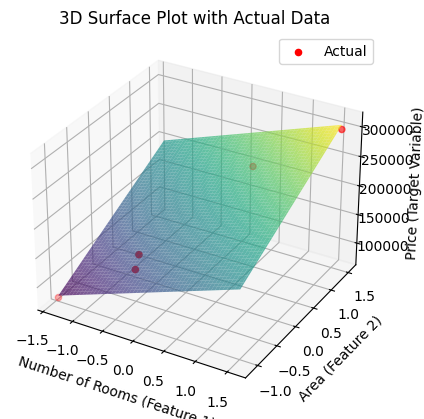

In [114]:
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

# Dữ liệu mẫu X_train với 2 đặc trưng và 5 mẫu
X_train = np.array([
    [1, 550],
    [2, 850],
    [2, 800],
    [4, 2000],
    [3, 1600],
])
y_train = np.array([78000, 150000, 130000, 300000, 250000])

# Chuẩn hóa X_train (sử dụng StandardScaler)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Khởi tạo trọng số w và bias b
initial_w = np.zeros(X_train.shape[1])  # Kích thước của w phải phù hợp với số đặc trưng (2)
initial_b = 0.

# Cấu hình gradient descent
iterations = 1500
alpha = 0.01

# Chạy gradient descent để tìm w, b
w, b, _, _ = gradient_descent(X_train, y_train, initial_w, initial_b, 
                              compute_cost, compute_gradient, alpha, iterations)

print("w,b found by gradient descent:", w, b)

# Tạo lưới các giá trị cho 2 đặc trưng (số phòng và diện tích)
x1_range = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(), 100)
x2_range = np.linspace(X_train[:, 1].min(), X_train[:, 1].max(), 100)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Tính toán giá trị dự đoán cho từng điểm trên lưới
z_grid = w[0] * x1_grid + w[1] * x2_grid + b

# Vẽ biểu đồ lưới 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Vẽ lưới dự đoán
ax.plot_surface(x1_grid, x2_grid, z_grid, cmap='viridis', alpha=0.7)

# Vẽ dữ liệu thực tế
ax.scatter(X_train[:, 0], X_train[:, 1], y_train, color='red', label='Actual')

# Thiết lập các nhãn cho trục
ax.set_xlabel('Number of Rooms (Feature 1)')
ax.set_ylabel('Area (Feature 2)')
ax.set_zlabel('Price (Target Variable)')
ax.set_title('3D Surface Plot with Actual Data')

plt.legend()
plt.show()


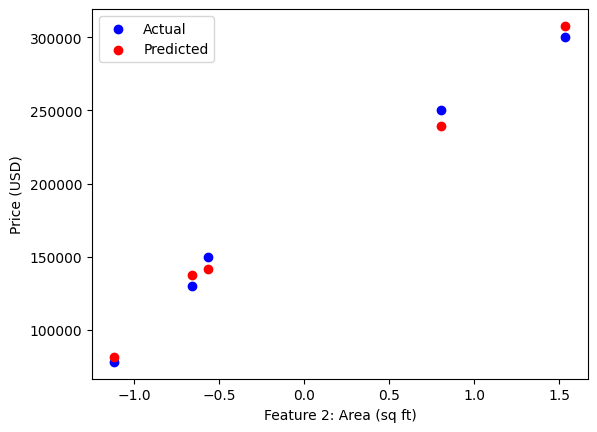

In [115]:
predicted = np.dot(X_train, w) + b  # Dự đoán giá nhà

# Vẽ đồ thị so sánh giá trị thực tế và giá trị dự đoán
plt.scatter(X_train[:, 1], y_train, color="blue", label="Actual")  # Giá trị thực tế
plt.scatter(X_train[:, 1], predicted, color="red", label="Predicted")  # Giá trị dự đoán
plt.legend()
plt.xlabel("Feature 2: Area (sq ft)")  # Diện tích
plt.ylabel("Price (USD)")  # Giá nhà
plt.show()